### Importing the dependencies

In [668]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### load the data

In [669]:
path ="../../../datasets/car_data.csv"
df =pd.read_csv(path)

### basic inspection

In [670]:
# First 5 rows
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [671]:
# Shape
print(f"rows: {df.shape[0]}\ncolumns: {df.shape[1]}")

rows: 301
columns: 9


In [672]:
# Info about the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [673]:
# Convert all column names to lowercase
df.columns = df.columns.str.lower()

In [674]:
# check duplicates values
df.duplicated().sum()

np.int64(2)

In [675]:
df[df.duplicated(keep=False)]

,car_name,year,selling_price,present_price,kms_driven,fuel_type,seller_type,transmission,owner
15,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
17,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
51,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0
93,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0


In [676]:
# droping duplicates values
df = df.drop_duplicates()

In [677]:
df.duplicated().sum()

np.int64(0)

In [678]:
# summary stats
df.describe()

,year,selling_price,present_price,kms_driven,owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.567887,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


### Univaraite Analysis

In [679]:
# distrubtion of categorical data
strings = list(df.select_dtypes(["str"]).columns)
strings

['car_name', 'fuel_type', 'seller_type', 'transmission']

In [680]:
# Convert all values into lowercase and check distrubtion
for col in strings:
    df[col]= df[col].str.lower()
    print(df[col].value_counts())
    print("_"*50)

car_name
city                   26
corolla altis          16
verna                  14
fortuner               10
brio                   10
                       ..
hero super splendor     1
hero hunk               1
hero  ignitor disc      1
hero  cbz xtreme        1
bajaj  ct 100           1
Name: count, Length: 98, dtype: int64
__________________________________________________
fuel_type
petrol    239
diesel     58
cng         2
Name: count, dtype: int64
__________________________________________________
seller_type
dealer        193
individual    106
Name: count, dtype: int64
__________________________________________________
transmission
manual       260
automatic     39
Name: count, dtype: int64
__________________________________________________


<Axes: xlabel='selling_price', ylabel='Count'>

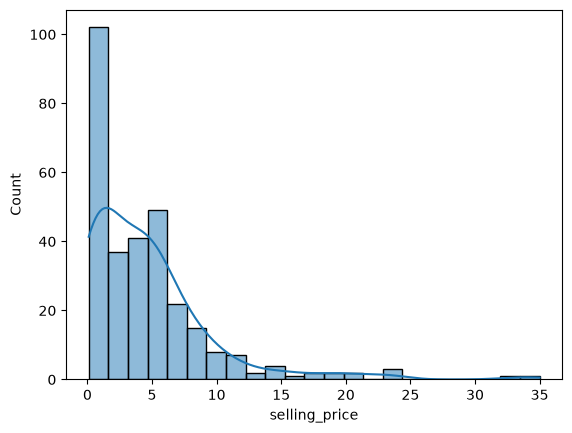

In [681]:
# distrubtion of selling_price
sns.histplot(df["selling_price"],kde=True)

<Axes: xlabel='present_price', ylabel='Count'>

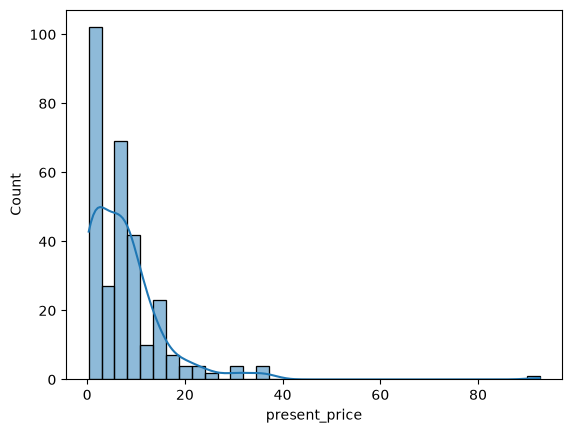

In [682]:
# distrubtion of present_price
sns.histplot(df["present_price"],kde=True)

In [683]:
df[df["present_price"]> 40]

,car_name,year,selling_price,present_price,kms_driven,fuel_type,seller_type,transmission,owner
86,land cruiser,2010,35.0,92.6,78000,diesel,dealer,manual,0


<Axes: xlabel='kms_driven', ylabel='Count'>

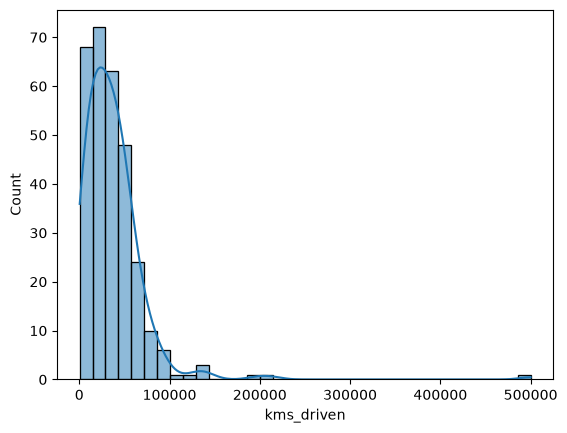

In [684]:
sns.histplot(df['kms_driven'],kde=True)

In [685]:
df[df["kms_driven"] >200000]

,car_name,year,selling_price,present_price,kms_driven,fuel_type,seller_type,transmission,owner
179,honda karizma,2010,0.31,1.05,213000,petrol,individual,manual,0
196,activa 3g,2008,0.17,0.52,500000,petrol,individual,automatic,0


### feature to target raltionship

<Axes: >

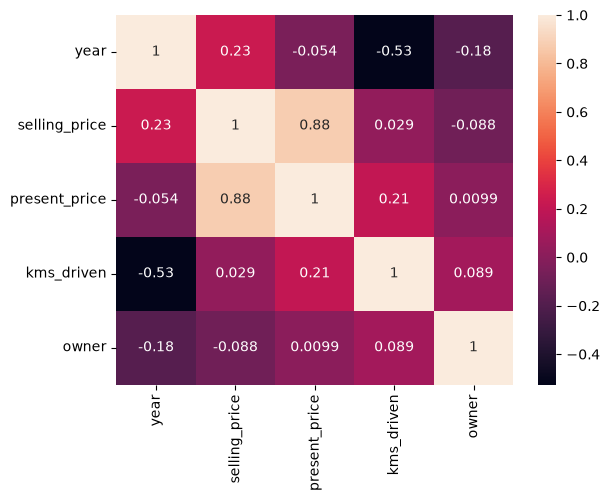

In [686]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [687]:
df = df.drop(["car_name"],axis=1)

### data preprocessing

**Encode categorical data**

In [688]:
df = pd.get_dummies(
    df,
    columns=["fuel_type", "seller_type", "transmission"],
    drop_first=True
)

In [689]:
df.sample(5)

,year,selling_price,present_price,kms_driven,owner,fuel_type_diesel,fuel_type_petrol,seller_type_individual,transmission_manual
296,2016,9.50,11.60,33988,0,True,False,False,True
165,2016,0.45,0.54,500,0,False,True,True,False
55,2009,3.60,15.04,70000,0,False,True,False,False
195,2015,0.18,0.32,35000,0,False,True,True,True
198,2011,0.15,0.57,35000,1,False,True,True,True


### Split the data into training and test data

In [690]:
# split the data into dependent and independent features
y = df.iloc[:,1]
X = df.drop(["selling_price"], axis=1)

In [691]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train , y_test = train_test_split(X,y,
                                                     test_size=0.1, random_state=42)
X_train.shape , X_test.shape , y_train.shape , y_test.shape

((269, 8), (30, 8), (269,), (30,))

### Train the model

In [692]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [693]:
# fit the model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.39, 0.42,-0. ,..., 0.72,-1.21,-1.23]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['year','present_price','kms_driven',...,'fuel_type_petrol', 'seller_type_individual','transmission_manual']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-780.4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [694]:
print(f"coefficient : {model.coef_}")
print(f"intercept: {model.intercept_}")

coefficient : [ 3.88575726e-01  4.22753747e-01 -4.62084190e-06 -7.11967057e-01
  2.39172158e+00  7.15929677e-01 -1.20582851e+00 -1.23423741e+00]
intercept: -780.3831282388896


### Model evaluation

In [695]:
# predication on the training data
train_pred = model.predict(X_train)

In [696]:
# R squared
from sklearn.metrics import r2_score
score = r2_score(y_train, train_pred)
print(f"r2 squared on training data : {score}")

r2 squared on training data : 0.888966058306142


In [697]:
# predication on test data
y_pred = model.predict(X_test)

In [698]:
score = r2_score(y_test, y_pred)
print(f"r2 squared test data : {score}")

r2 squared test data : 0.8254816065924475


### visualize the actual price and predicated price

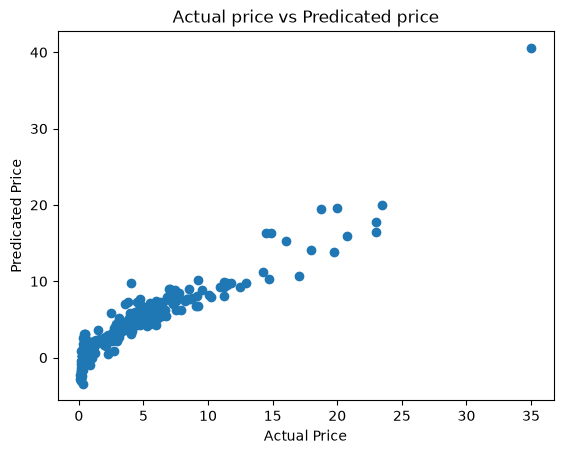

In [699]:
plt.scatter(y_train, train_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicated Price")
plt.title("Actual price vs Predicated price")
plt.show()

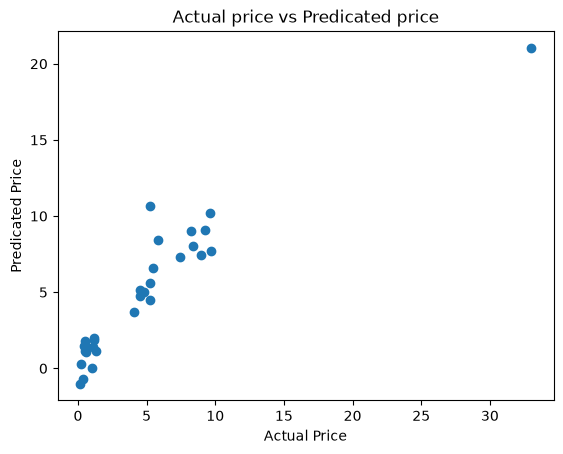

In [700]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicated Price")
plt.title("Actual price vs Predicated price")
plt.show()

### Lasso regression

In [701]:
from sklearn.linear_model import Lasso
lass_model = Lasso()

In [702]:
lass_model.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [703]:
# predication on the training data
train_pred = lass_model.predict(X_train)

In [704]:
# R squared
from sklearn.metrics import r2_score
score = r2_score(y_train, train_pred)
print(f"r2 squared on training data : {score}")

r2 squared on training data : 0.8489600574132006


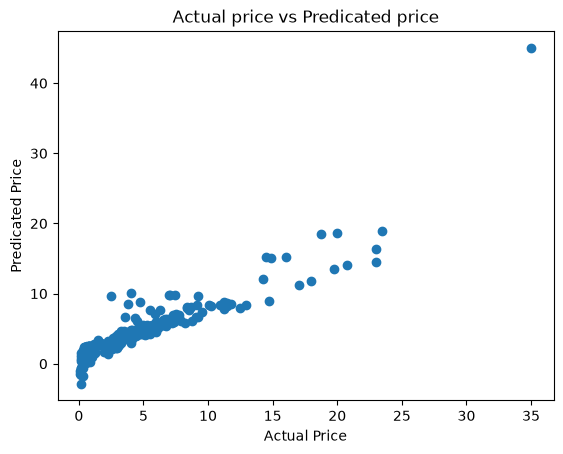

In [705]:
plt.scatter(y_train, train_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicated Price")
plt.title("Actual price vs Predicated price")
plt.show()

In [706]:
# predication on test data
y_pred = lass_model.predict(X_test)

In [707]:
score = r2_score(y_test, y_pred)
print(f"r2 squared test data : {score}")

r2 squared test data : 0.7781603158900109


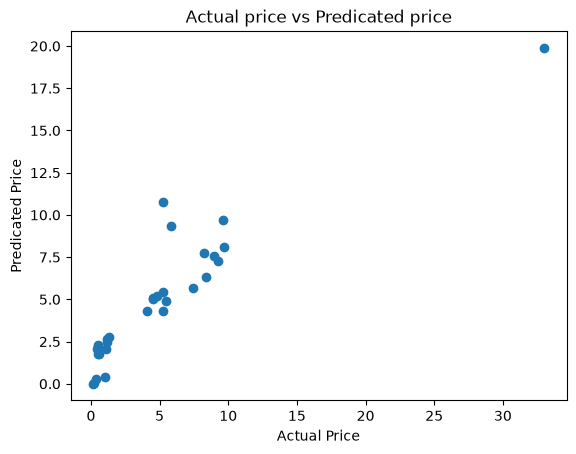

In [708]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicated Price")
plt.title("Actual price vs Predicated price")
plt.show()